# Applying various transformations to images

### This notebook will go through the procedure by which various tranformations can be applied to images in order to deepen the understanding of underlying methods of libraries like numpy
- Scaling
- Rotation
- GreyScaling

In [1]:
from utils.imports import *
import math

### Part 1: Rotation

#### Let's start by aplying a rotational tranformation to a simple 1-D matrix (a vector)

In [2]:
# original point
a=np.array(
    [[2],[2]]
    )
print(a.ndim)

2


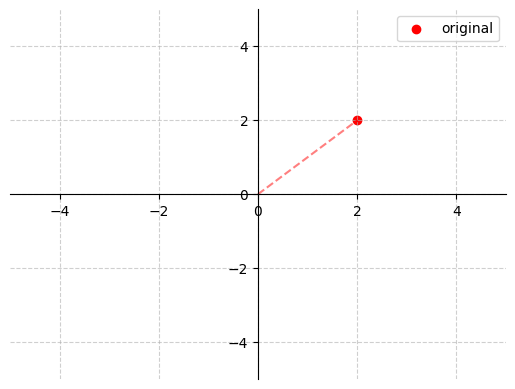

In [3]:

left_rotation_mat= np.array(
    [[0,-1],
    [1,0]]
)
# Plot the point
plt.scatter(a[0, 0], a[1, 0], color='red', label='original')
# Plot the line from origin (0,0) to point (a[0], a[1])
plt.plot([0, a[0, 0]], [0, a[1, 0]], color='red', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.show()

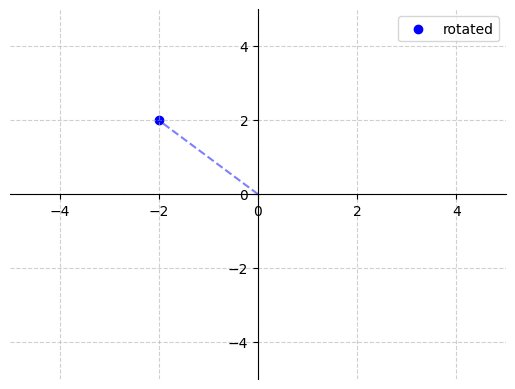

In [4]:
rotated_matrix = b = left_rotation_mat @ a
# Plot the point
plt.scatter(b[0, 0], b[1, 0], color='blue', label='rotated')
# Plot the line from origin (0,0) to point (b[0], b[1])
plt.plot([0, b[0, 0]], [0, b[1, 0]], color='blue', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.show()

#### Let's see how this translates to rotating an image

In [5]:
# load the image
img = Image.open('inputs/ghost.jpg')
img_array= np.asarray(img)
print(img_array.shape)

(2360, 2360, 3)


##### Rotating an Image
The image array has a shape of 474,474,4 which means, it has 
- 474 px in height
- 474 px in length
- 4 dimensions of color (r,g,b,opacity)

Now let's say we ignore the color channels for now. The image matrix becomes a 474x474 matrix which needs to be rotated.
BUT the images aren't defined with pixels centered at the center of the image, i.e the origin of image pixels is
at the top left. SO we'll need to shift the origin to the center.
The process will be:
1. shift the center
2. rotate the positions
3. shift the center back (for the rotation to take place in the original image)
BUTTTTT there's one more catch.... guess what.. the image matrix without the color channels isn't anything..
WHY? cos color channels are what **MAKE** the image. So we'll have to actually transform the color channels
Hence the next step would be:
4. copy the color channel info from the original matrix to the rotated matrix

In [6]:
h, w, c = img_array.shape
center_y, center_x = h // 2, w // 2
angle = 45
theta = math.radians(angle)

rot_mat = np.array([
    [math.cos(theta), -math.sin(theta)],
    [math.sin(theta), math.cos(theta)]
])
'''
when NumPy says the shape is (474, 474, 4), it means:
shape[0] = 474 **Rows** (Vertical / Height / Y)
shape[1] = 474 **Columns** (Horizontal / Width / X)
'''
Y= np.arange(img_array.shape[0]) # creates an array like [0,1,2....473] from the Y component of the array
X= np.arange(img_array.shape[1]) # creates an array like [0,1,2....473] from the X component of the array

x_grid,y_grid=np.meshgrid(X,Y)
'''
meshgrid created the combinations of all x and y coordinates, essentially creating the whole space where
any pixel from the 474x474 image can lie
'''
# shifting the center
x_grid= x_grid-center_x # x_grid = (474,474)
y_grid= y_grid-center_y # y_grid = (474,474)
image_mat=np.vstack([x_grid.ravel(),y_grid.ravel()])
'''
^^this creates the ACTUAL matrix OF all possible coordinates, that has to be rotated^^
'''
rotated_image=rot_mat@image_mat

In [7]:
# the image is rotated, now we copy the colors, buuuutttt, the rotation has caused non integer values to occur in the matrix
rotated_image= np.round(rotated_image)
# now the corrdinates should be integers, let's copy the colors now
# current rotated_image is a (2,474*474) matrix

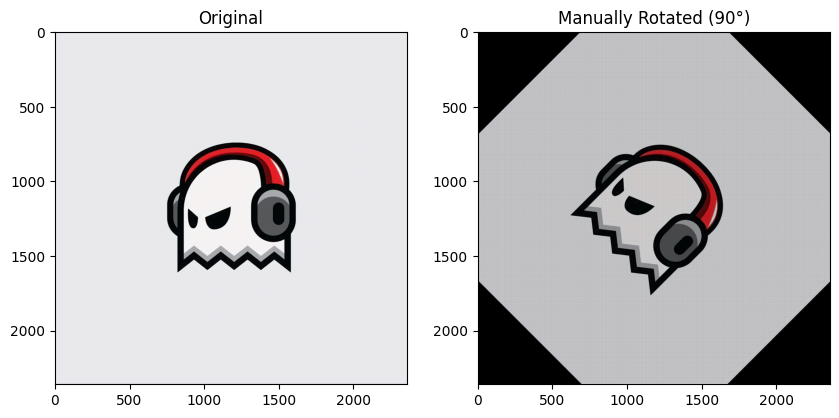

<Figure size 640x480 with 0 Axes>

In [8]:
# 1. CHANGE OF BASIS (BACKWARD): Shift results back to the standard image origin
# In Chapter 3, this is the final step (B^-1) of a Similarity Transformation Sandwich.
# We are translating our vectors from "Center-Language" back to "Top-Left Language."
x_dest = (rotated_image[0, :] + center_x).astype(int)
y_dest = (rotated_image[1, :] + center_y).astype(int)

# 2. Recover the source coordinates for the color pull
# Since we are doing Forward Mapping, we need to know which pixel in the original 
# img_array corresponds to each point in our flattened matrix.
x_src = (x_grid.ravel() + center_x).astype(int)
y_src = (y_grid.ravel() + center_y).astype(int)

# 3. THE BOUNDARY PROBLEM: Filter out pixels that "flew off" the grid during rotation.
mask = (x_dest >= 0) & (x_dest < w) & (y_dest >= 0) & (y_dest < h)

# 4. Initialize our final image canvas
rotated_img_final = np.zeros_like(img_array)

# 5. THE PAYLOAD TRANSFER: Apply the 4-channel color (RGBA) to the new addresses.
# This is where the geometric transformation (the map) meets the raw data (the color).
rotated_img_final[y_dest[mask], x_dest[mask], :] = img_array[y_src[mask], x_src[mask], :]

# 6. Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img_array)

plt.subplot(1, 2, 2)
plt.title("Manually Rotated (90°)")
plt.imshow(rotated_img_final)
plt.show()
plt.savefig('outputs/maskedop.png')

##### What happens without the Mask?

If we didn't use the `mask`, two things would happen:
1. **The Crash:** Any pixel that rotates to a position $> 473$ would cause an `IndexError`. Python would stop the code immediately because it doesn't know where to put that data.
2. **The Wrap-Around:** For negative indices (like $-5$), NumPy wouldn't crash. Instead, it would "wrap around" and paint the pixel on the opposite side of the image (since `array[-1]` is the last element).

Let's simulate what this "Wrap-Around" looks like using the modulo operator (`%`) to avoid the crash:

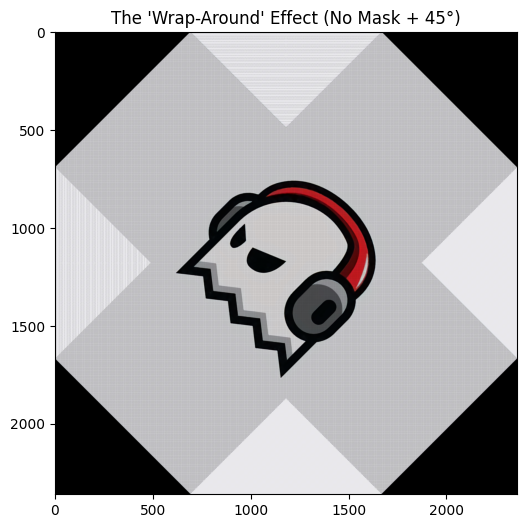

<Figure size 640x480 with 0 Axes>

In [9]:
# To see the effect, let's use a 45 degree angle so corners fly off the screen
theta_45 = np.radians(45)
rot_45 = np.array([
    [np.cos(theta_45), -np.sin(theta_45)],
    [np.sin(theta_45), np.cos(theta_45)]
])

rotated_45 = rot_45 @ image_mat
x_45 = (rotated_45[0, :] + center_x).astype(int)
y_45 = (rotated_45[1, :] + center_y).astype(int)

# Simulating NO MASK using modulo (to force the pixels back onto the screen)
x_no_mask = x_45 % w
y_no_mask = y_45 % h

img_no_mask = np.zeros_like(img_array)
img_no_mask[y_no_mask, x_no_mask, :] = img_array[y_src, x_src, :]

plt.figure(figsize=(6, 6))
plt.title("The 'Wrap-Around' Effect (No Mask + 45°)")
plt.imshow(img_no_mask)
plt.show()
plt.savefig('outputs/nonmaskedop.jpg')

##### Mathematical Breakdown: The Wrap-Around Effect

In the results (`maskedop.png` vs `nonmaskedop.jpg`), we are seeing a conflict between **Linear Algebra** and **Array Indexing**.

1. The Clean Masked Output:  
    When we use the `mask`, we are enforcing a **Boundary Condition**. Mathematically, we are defining our transformation only for the subset of points where:
    $$ \vec{v}' \in [0, W] \times [0, H] $$
    If a point $\vec{v}'$ lands outside this box (like at coordinate $500$ in a $474$px image), the mask returns `False`, and we simply don't paint anything. This results in the clean black background around the rotated ghost.

2. The Unmasked "Wrap-Around":  
    In the unmasked version, you see pieces of the ghost "re-appearing" on the opposite side. This is caused by **Negative Indexing** and **Modulo Logic**.

    **Example: The Edge of the Ghost**  
    Imagine a pixel at the edge of the ghost rotates to a new position of $(-10, 200)$. 
    - **Geometrically:** This point is $10$ pixels to the **left** of the image border.
    - **Computationally:** In a NumPy array of width $474$, the index `-10` is interpreted as `474 - 10 = 464`.

    So, instead of disappearing into space, the pixel "wraps around" the cylinder of the image memory and gets painted at the **far right** edge. 

3. The Modulo Visual:  
    You can think of the unmasked image as being mapped onto a **Torus** (a donut shape). 
    $$ x_{index} = x_{calc} \pmod W $$
    $$ y_{index} = y_{calc} \pmod H $$

    When a pixel "exits" through the right wall, it immediately "enters" through the left wall. This is why the unmasked image looks like a fragmented puzzle—you are seeing a 2D projection of a continuous coordinate loop!

### Part 2: Flipping

In [26]:
# load the image
img= Image.open('inputs/ghost.jpg')
np_img = np.asarray(img)
print(np_img.shape)

(2360, 2360, 3)


In [27]:
# shifting the center
x_shift=y_shift=2360//2
X,Y=np.meshgrid(np.arange(np_img.shape[1]), np.arange(np_img.shape[0]))
X=X-x_shift
Y=Y-y_shift
img_arr=np.vstack([X.ravel(),Y.ravel()])


In [28]:
# the flipping matrix
flipper= np.array(
    [[-1,0],
    [0,1]])
#transform the image
flipped_img= flipper @ img_arr


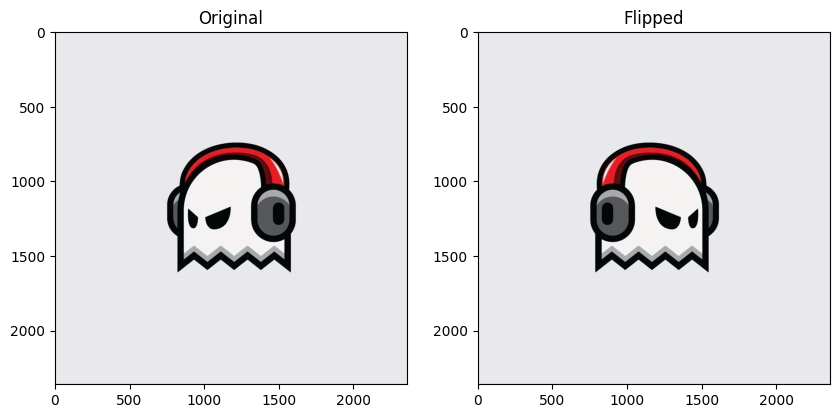

<Figure size 640x480 with 0 Axes>

In [35]:
x_dest = (flipped_img[0, :] + x_shift).astype(int)
y_dest = (flipped_img[1, :] + y_shift).astype(int)
x_src = (X.ravel() + x_shift).astype(int)
y_src = (Y.ravel() + y_shift).astype(int)

h=w=np_img.shape[0]
# 3. THE BOUNDARY PROBLEM: Filter out pixels that "flew off" the grid during rotation.
mask = (x_dest >= 0) & (x_dest < w) & (y_dest >= 0) & (y_dest < h)

# 4. Initialize our final image canvas
flipped_img_final = np.zeros_like(np_img)

# 5. THE PAYLOAD TRANSFER: Apply the 4-channel color (RGBA) to the new addresses.
# This is where the geometric transformation (the map) meets the raw data (the color).
flipped_img_final[y_dest[mask], x_dest[mask], :] = np_img[y_src[mask], x_src[mask], :]

# 6. Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(np_img)

plt.subplot(1, 2, 2)
plt.title("Flipped")
plt.imshow(flipped_img_final)
plt.show()
plt.savefig('outputs/masked-flip.png')

### Part 3: Zoom/Scaling

In [31]:
# image load and array prep

img = Image.open('inputs/ghost.jpg')
np_img = np.asarray(img)
print(np_img.shape)

(2360, 2360, 3)


In [32]:
c_shift= 2360 //2
X,Y=np.meshgrid(np.arange(2360), np.arange(2360))
X= X-c_shift
Y= Y-c_shift
img_arr=np.vstack((X.ravel(),Y.ravel()))

In [36]:
# transformation
zoomer = np.array([
    [2,0],
    [0,2]
])

zoomed_img=zoomer @ img_arr

# we don't need it, but okay
zoomed_img = np.round(zoomed_img)

x_dest = (zoomed_img[0,:]+c_shift).astype(int)
y_dest = (zoomed_img[1,:]+c_shift).astype(int)

x_src = (X.ravel() + x_shift).astype(int)
y_src = (Y.ravel() + y_shift).astype(int)

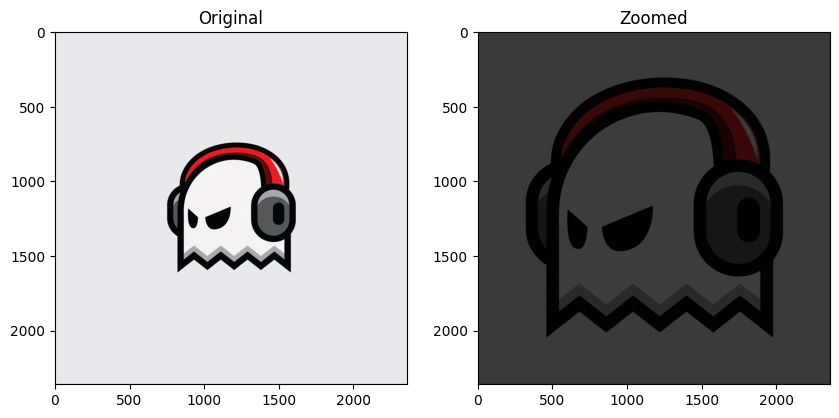

<Figure size 640x480 with 0 Axes>

In [38]:
#plotting
h=w=np_img.shape[0]
# 3. THE BOUNDARY PROBLEM: Filter out pixels that "flew off" the grid during rotation.
mask = (x_dest >= 0) & (x_dest < w) & (y_dest >= 0) & (y_dest < h)

# 4. Initialize our final image canvas
zoomed_img_final = np.zeros_like(np_img)

# 5. THE PAYLOAD TRANSFER: Apply the 4-channel color (RGBA) to the new addresses.
# This is where the geometric transformation (the map) meets the raw data (the color).
zoomed_img_final[y_dest[mask], x_dest[mask], :] = np_img[y_src[mask], x_src[mask], :]

# 6. Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(np_img)

plt.subplot(1, 2, 2)
plt.title("Zoomed")
plt.imshow(zoomed_img_final)
plt.show()
plt.savefig('outputs/masked-flip.png')